## Reading Data

In [ ]:
import pandas as pd

df = pd.read_csv("insurance.csv")

## Getting infos and describe Data

In [48]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
df.shape

(1337, 7)

In [57]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [50]:
df.info()


<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


In [51]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [52]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## One duplicate record was found and removed from the dataset to avoid duplicate observations affecting the analysis.

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges


## We dropped the duplicate

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
df.duplicated().sum()

np.int64(0)

## The dataset has a nearly balanced distribution between males and females, with 675 males and 662 females.

In [58]:
df["sex"].value_counts()


sex
male      675
female    662
Name: count, dtype: int64

## Most individuals in the dataset are non-smokers, while smokers represent a smaller portion of the dataset.

In [59]:
df["smoker"].value_counts()


smoker
no     1063
yes     274
Name: count, dtype: int64

In [60]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

C:\Users\ALIENWARE\AppData\Local\Temp\ipykernel_4136\180360222.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["charges"], vert=False)


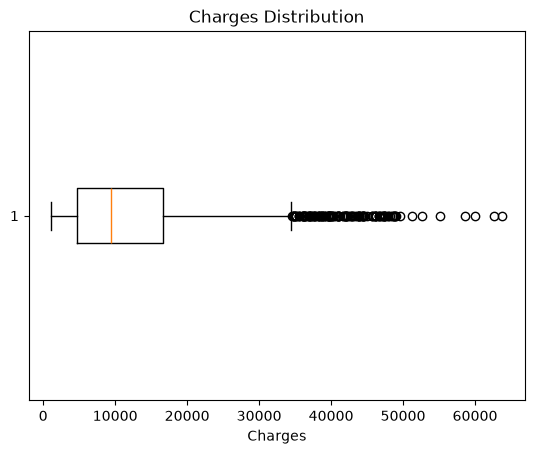

In [61]:
import matplotlib.pyplot as plt

plt.boxplot(df["charges"], vert=False)
plt.title("Charges Distribution")
plt.xlabel("Charges")
plt.show()

## Smokers have much higher insurance charges than non-smokers. The average charge for smokers is about 3.8 times higher than for non-smokers, showing a strong association between smoking status and insurance charges.

In [62]:
df.groupby("smoker")["charges"].describe().T

smoker,no,yes
count,1063.000000,274.000000
mean,8440.660307,32050.231832
std,5992.973800,11541.547176
min,1121.873900,12829.455100
25%,3988.883500,20826.244213
50%,7345.726600,34456.348450
75%,11363.019100,41019.207275
max,36910.608030,63770.428010


In [63]:
df.groupby("sex")["charges"].mean()

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

## Smoking status is strongly associated with higher insurance charges for both males and females. The difference between males and females is more noticeable among smokers than non-smokers.

In [64]:
df.groupby(["sex", "smoker"])["charges"].mean()

sex     smoker
female  no         8762.297300
        yes       30678.996276
male    no         8099.700161
        yes       33042.005975
Name: charges, dtype: float64

## Insurance charges generally increase with age, although the average charges fluctuate across individual age groups.

In [65]:
df.groupby("age")["charges"].mean()

age
18     7086.217556
19     9868.929428
20    10159.697736
21     4730.464330
22    10012.932802
23    12419.820040
24    10648.015962
25     9838.365311
26     6133.825309
27    12184.701721
28     9069.187564
29    10430.158727
30    12719.110358
31    10196.980573
32     9220.300291
33    12351.532987
34    11613.528121
35    11307.182031
36    12204.476138
37    18019.911877
38     8102.733674
39    11778.242945
40    11772.251310
41     9653.745650
42    13061.038669
43    19267.278653
44    15859.396587
45    14830.199856
46    14342.590639
47    17653.999593
48    14632.500445
49    12696.006264
50    15663.003301
51    15682.255867
52    18256.269719
53    16020.930755
54    18758.546475
55    16164.545488
56    15025.515837
57    16447.185250
58    13878.928112
59    18895.869532
60    21979.418507
61    22024.457609
62    19163.856573
63    19884.998461
64    23275.530837
Name: charges, dtype: float64

## Insurance charges tend to increase as age increases, indicating a positive relationship between age and insurance charges.

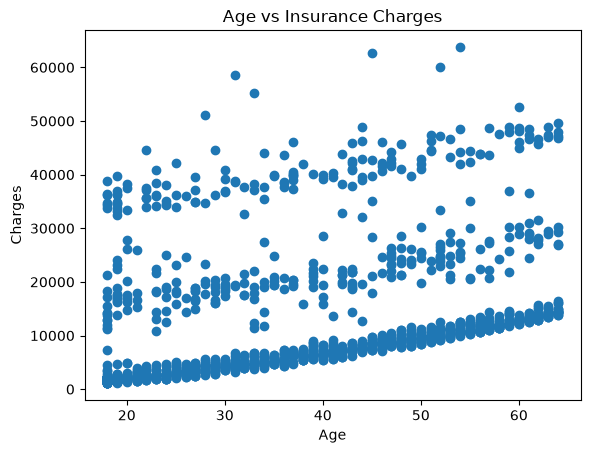

In [66]:
import matplotlib.pyplot as plt

plt.scatter(df["age"], df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

## so here we came up with a question does smoking and age affeect on charges

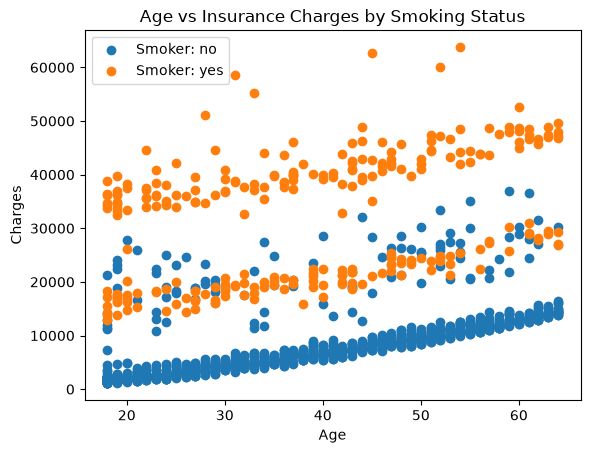

In [67]:
import matplotlib.pyplot as plt

for status in ["no", "yes"]:
    data = df[df["smoker"] == status]
    plt.scatter(data["age"], data["charges"], label=f"Smoker: {status}")

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend()
plt.show()

## BMI shows a weak positive relationship with insurance charges, but BMI alone does not clearly explain the variation in charges.

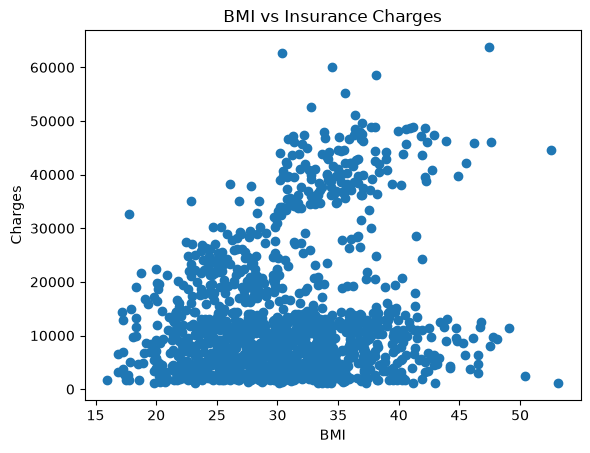

In [68]:
plt.scatter(df["bmi"], df["charges"])
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

## Smoking status is strongly associated with higher insurance charges, even across different BMI levels.

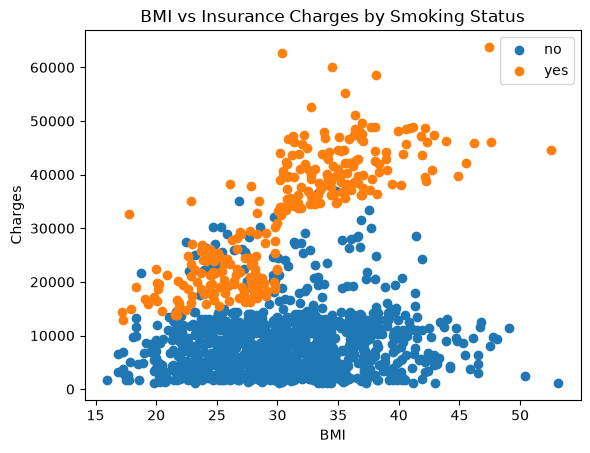

In [69]:
for status in ["no", "yes"]:
    data = df[df["smoker"] == status]
    plt.scatter(data["bmi"], data["charges"], label=status)

plt.title("BMI vs Insurance Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend()
plt.show()

## The number of children does not show a clear relationship with insurance charges, and the groups with 4–5 children are too small to draw strong conclusions.

In [70]:
df.groupby("children")["charges"].mean()

children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

In [71]:
df["children"].value_counts().sort_index()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

## Insurance charges are relatively similar across regions, with Northeast having the highest average charges. However, the regional differences are relatively small.

In [72]:
df.groupby("region")["charges"].mean()

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [73]:
df.groupby("sex")["charges"].agg(["count", "mean"])

,count,mean
sex,,
female,662,12569.578844
male,675,13974.998864


In [74]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


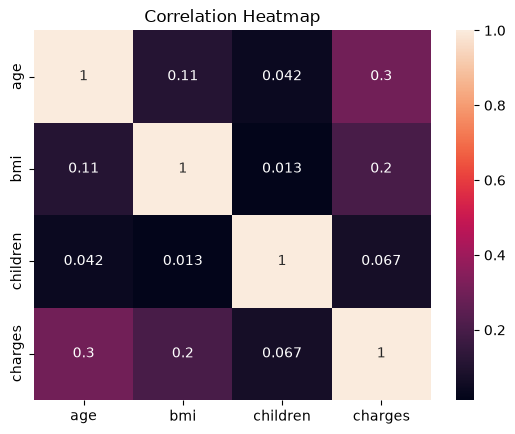

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

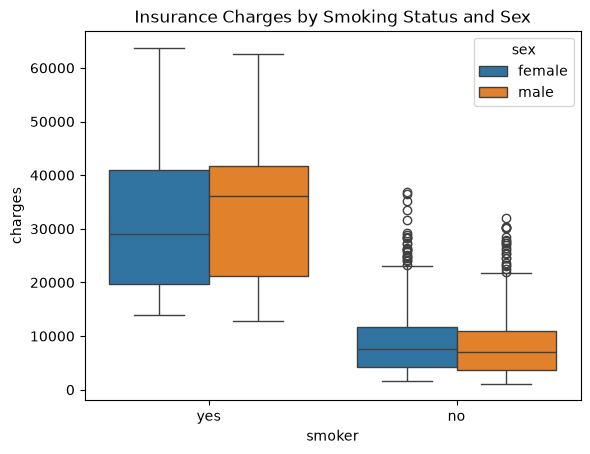

In [76]:
sns.boxplot(data=df, x="smoker", y="charges", hue="sex")
plt.title("Insurance Charges by Smoking Status and Sex")
plt.show()